In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm


In [3]:
with np.load('cifar10_kaggle.npz', allow_pickle=True) as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test = f['x_test']

    
X = x_train
y = y_train



In [4]:
label_map = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}


In [5]:
X.shape, y.shape

((50000, 32, 32, 3), (50000, 1))

In [6]:
y[0].item()

6

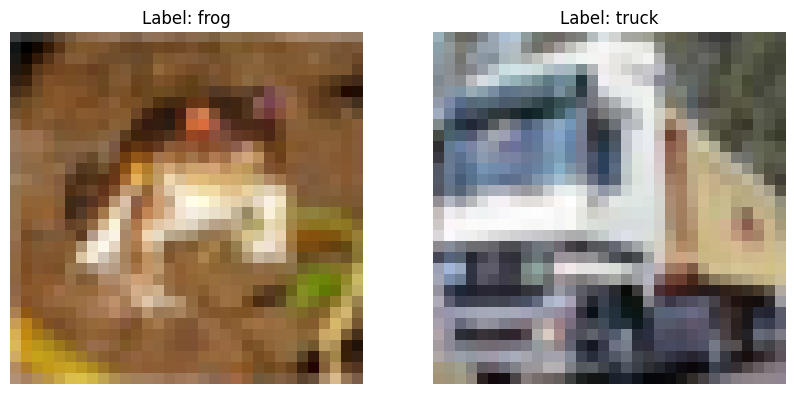

In [7]:
indices = [0, 1] # 随机选择一些样本的索引
fig, axes = plt.subplots(1, len(indices), figsize=(10, 5))

for i, idx in enumerate(indices):
    axes[i].imshow(X[idx])
    axes[i].set_title(f"Label: {label_map[(y[idx].item())]}")
    axes[i].axis('off') 
    
plt.show()





In [8]:
#标准化
X = X / X.max()

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)


In [9]:
dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

len(train_dataset), len(val_dataset)


(40000, 10000)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)#输出尺寸减半
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(128 * 4 * 4, 512)#输入尺寸是128*4*4，因为经过三次池化后，图像尺寸从32x32变为4x4
        self.fc2 = nn.Linear(512, 10)
        
    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous()#调整输入数据的维度顺序，从(batch_size, height, width, channels)变为(batch_size, channels, height, width)
        x = self.pool(self.relu(self.conv1(x)))#3*32x32 -> 32*16x16
        x = self.pool(self.relu(self.conv2(x)))#32*16x16 -> 64*8x8
        x = self.pool(self.relu(self.conv3(x)))#64*8x8 -> 128*4x4
        x = x.view(x.size(0), -1) #展平
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
        
        

In [12]:
#残差神经网络，带 BN 和 Dropout
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.match_channels = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.dropout = nn.Dropout(0.25)
        
    def forward(self, x):
        identity = x
        x = self.relu(self.bn1(self.conv1(x)))  
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        
        identity = self.match_channels(identity)
        x += identity
        x = self.relu(x)
        return x

In [13]:
class ResNet(nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()
        # 第一层残差块：输入通道3（RGB图像），输出通道32，卷积核大小3x3
        self.res_block1 = ResNetBlock(3, 32)
        # 第二层残差块：输入通道32，输出通道64，卷积核大小3x3
        self.res_block2 = ResNetBlock(32, 64)
        # 第三层残差块：输入通道64，输出通道128，卷积核大小3x3
        self.res_block3 = ResNetBlock(64, 128)
        # 池化层：2x2最大池化，减少空间维度
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 输出：128 x 16 x 16
        # ReLU激活函数（将用于卷积层输出后的激活）
        self.relu = nn.ReLU()
        # 全连接层
        self.fc1 = nn.Linear(128 * 4 * 4, 512)  # 将卷积输出展平后接全连接层
        self.bn_fc1 = nn.BatchNorm1d(512)  # 对全连接层输入进行批量归一化
        self.dropout_fc1 = nn.Dropout(0.5)  # Dropout层，丢弃50%的神经元
        self.fc2 = nn.Linear(512, 10)  # 输出10类

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous()   
        # 保证输入是32x32的图像# 第一层残差块        
        x = self.res_block1(x)  
        # 输入：3x32x32 -> 输出：32x32x32        
        x = self.pool(x)  
        # 池化层，输出：32x16x16# 第二层残差块        
        x = self.res_block2(x)  
        # 输入：32x16x16 -> 输出：64x16x16        
        x = self.pool(x)  # 池化层，输出：64x8x8# 第三层残差块        
        x = self.res_block3(x)  # 输入：64x8x8 -> 输出：128x8x8        
        x = self.pool(x)  # 池化层，输出：128x4x4# 展平多维输入数据为一维        
        x = x.view(x.size(0), -1)  # 自动计算展平后的大小# 全连接层，批量归一化，激活函数，Dropout        
        x = self.relu(self.bn_fc1(self.fc1(x)))  # 全连接层 -> BN -> ReLU        
        x = self.dropout_fc1(x)  # Dropout        
        x = self.fc2(x)  # 输出层
        return x

In [14]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print("Using CPU")


Using CPU


In [15]:
model = ResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
val_accuracies = []
train_loss_per_step = []

num_epochs = 25
for epoch in range(num_epochs):
    #1.训练阶段
    model.train()
    running_loss = 0.0 #累计损失
    for i, (inputs, labels) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        # print('inputs', inputs.shape)
        outputs = model(inputs)
        # print('outputs', outputs.shape)
        # print('labels', labels.shape)
        labels = labels.squeeze(1)#将标签张量从形状(batch_size, 1)转换为(batch_size,)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        train_loss_per_step.append(loss.item())
        
        if (i + 1) % 100 == 0: #每100个批次记录一次损失
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}")
            
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    
    #2.验证阶段
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            labels = labels.squeeze(1)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)#获取每行最大值的索引，即预测的类别
            total += labels.size(0)#统计总样本数
            correct += (predicted == labels).sum().item()#统计预测正确的样本数
    
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    
            
    

Epoch 1/25:  15%|█▍        | 92/625 [00:15<01:27,  6.08it/s]


KeyboardInterrupt: 

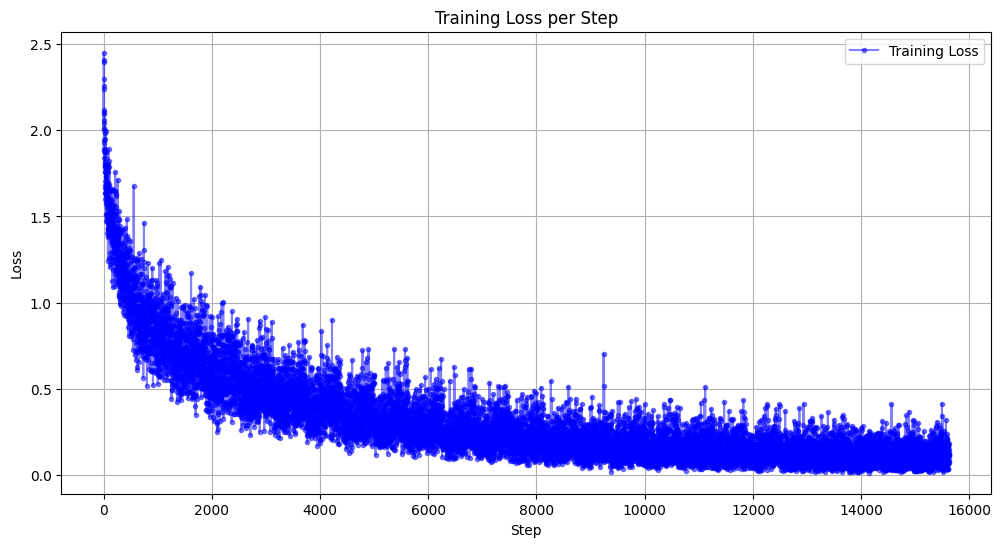

In [ ]:
#绘制每一步的损失曲线
plt.figure(figsize=(12, 6))
plt.plot(train_loss_per_step, label='Training Loss',color='blue', alpha=0.5, marker='o', markersize=3)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss per Step')
plt.legend()
plt.grid(True)
plt.show()

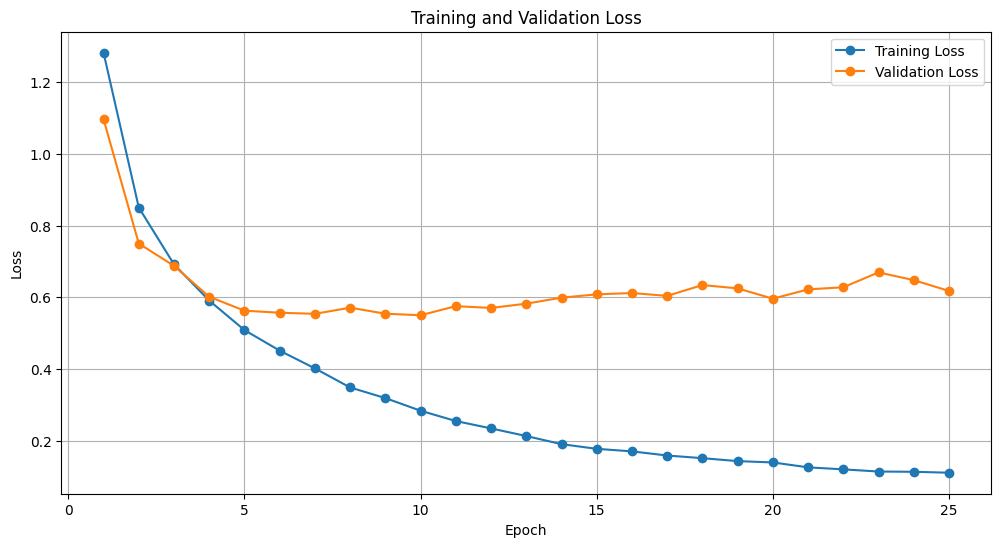

In [ ]:
#绘制损失曲线
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


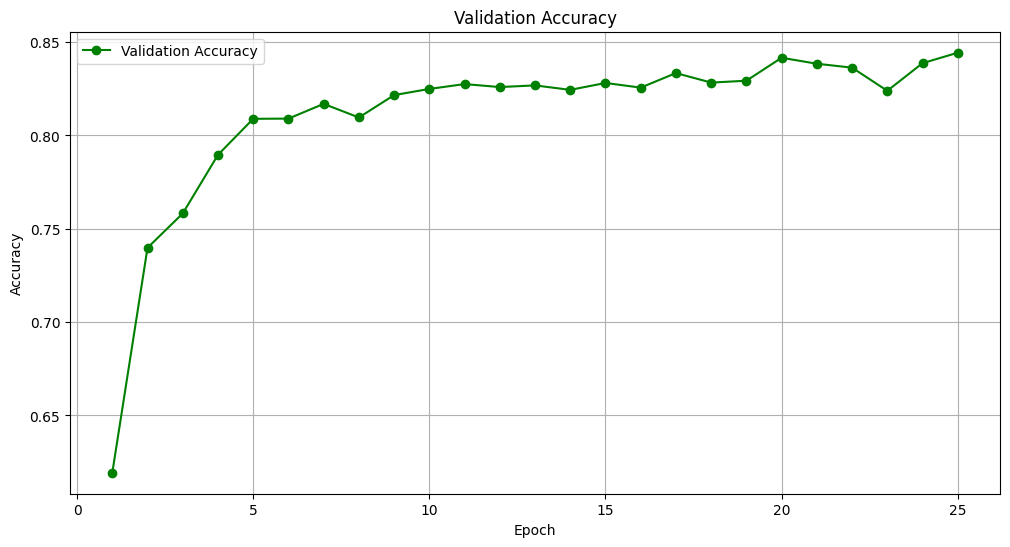

In [ ]:
#绘制准确率曲线
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_test = x_test
X_test = X_test / 255.0

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()

all_images = []
all_predictions = []

with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs[0].to(device) #因为test_loader的每个元素是一个元组，所以取第一个元素
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_images.extend(inputs.view(-1, 32, 32).cpu().numpy()) #将输入图像添加到列表中
        all_predictions.extend(predicted.cpu().numpy()) #将预测结果添加到列表中

all_predictions[:5]


[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

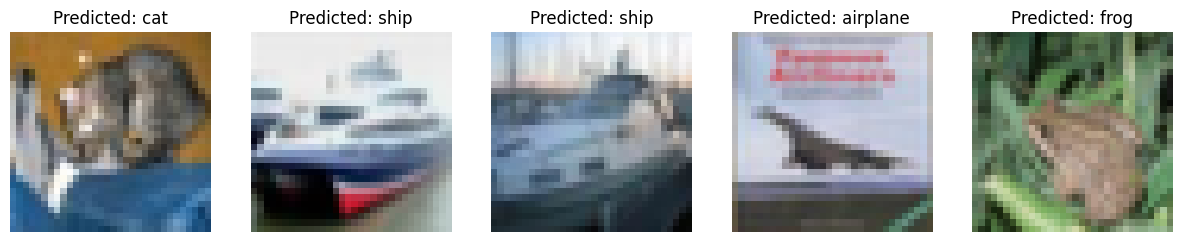

In [ ]:
num_images_to_show = 5
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(num_images_to_show):
    axes[i].imshow(x_test[i])
    axes[i].set_title(f"Predicted: {label_map[(all_predictions[i]).item()]}")
    axes[i].axis('off')
    


In [ ]:
image_ids = range(0, len(all_predictions))
image_ids

NameError: name 'all_predictions' is not defined

In [ ]:
result_df = pd.DataFrame({
    'Id': image_ids,
    'Category': all_predictions
})

result_df.head()


,Id,Category
0,1,3
1,2,8
2,3,8
3,4,0
4,5,6


In [ ]:
result_df.to_csv('cifar10_predictions.csv', index=False)
print("Predictions saved to cifar10_predictions.csv")


Predictions saved to cifar10_predictions.csv


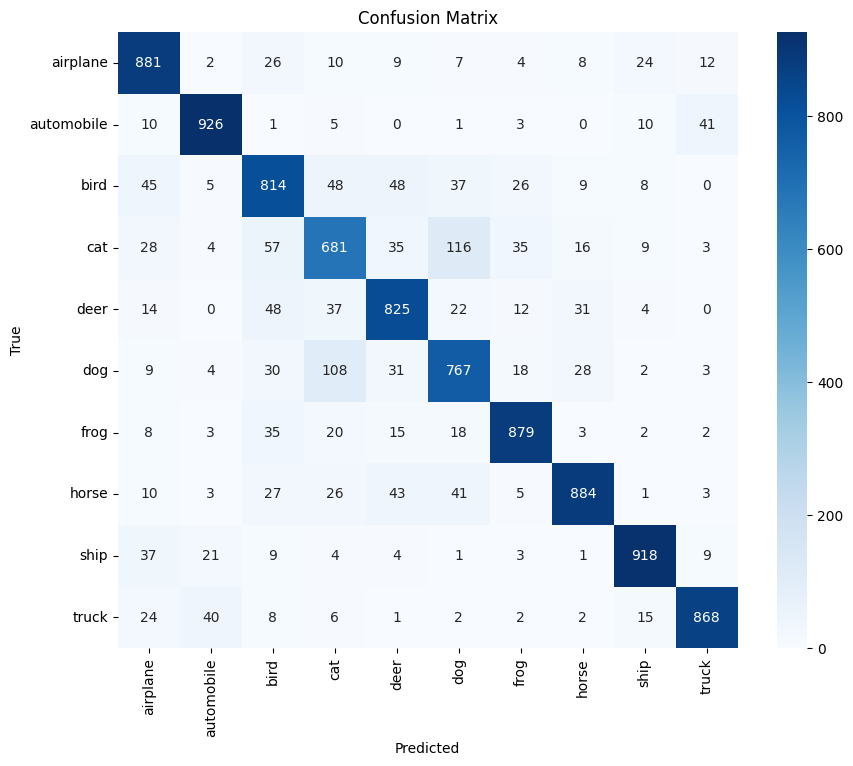

In [ ]:
#用于存储预测标签和真实标签
#注意这里是对验证集进行混淆矩阵打印，因为 test 没有label

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        labels = labels.squeeze(1)
        _, predicted = torch.max(outputs.data, 1)
        
        #保存真实标签和预测标签
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()